In [1]:
#Weather Data Preprocessing

In [2]:
import pandas as pd
import missingno as msno
%matplotlib inline

In [3]:

airports = ("ATL", "CLT", "DEN", "DFW", "EWR", "IAH", "JFK", "LAS", "LAX", "MCO", "MIA", "ORD", "PHX", "SEA", "SFO")
columns = ("windspeedKmph",
          "winddirDegree", 
          "weatherCode",
          "precipMM",
          "visibility",
          "pressure",
          "cloudcover",
          "DewPointF",
          "WindGustKmph",
          "tempF",
          "WindChillF",
          "humidity",
          "date",
          "time")
years = ("2016", "2017")

In [4]:
#data loaded and cleaned
weather_data = list()
for city in airports:
    for year in years:
        for month in range(1, 12+1):
            file = f"Data/weather/{city}/{year}-{month}.json"
            df = pd.read_json(file)
            wd = df["data"]["weather"] # list
            wd_df = pd.json_normalize(data=wd)
            wd_df = pd.json_normalize(data=wd, record_path="hourly", meta="date")
            wd_df = wd_df[list(columns)]
            wd_df["airport"] = city
            weather_data.append(wd_df)
            print(file)


Data/weather/ATL/2016-1.json
Data/weather/ATL/2016-2.json
Data/weather/ATL/2016-3.json
Data/weather/ATL/2016-4.json
Data/weather/ATL/2016-5.json
Data/weather/ATL/2016-6.json
Data/weather/ATL/2016-7.json
Data/weather/ATL/2016-8.json
Data/weather/ATL/2016-9.json
Data/weather/ATL/2016-10.json
Data/weather/ATL/2016-11.json
Data/weather/ATL/2016-12.json
Data/weather/ATL/2017-1.json
Data/weather/ATL/2017-2.json
Data/weather/ATL/2017-3.json
Data/weather/ATL/2017-4.json
Data/weather/ATL/2017-5.json
Data/weather/ATL/2017-6.json
Data/weather/ATL/2017-7.json
Data/weather/ATL/2017-8.json
Data/weather/ATL/2017-9.json
Data/weather/ATL/2017-10.json
Data/weather/ATL/2017-11.json
Data/weather/ATL/2017-12.json
Data/weather/CLT/2016-1.json
Data/weather/CLT/2016-2.json
Data/weather/CLT/2016-3.json
Data/weather/CLT/2016-4.json
Data/weather/CLT/2016-5.json
Data/weather/CLT/2016-6.json
Data/weather/CLT/2016-7.json
Data/weather/CLT/2016-8.json
Data/weather/CLT/2016-9.json
Data/weather/CLT/2016-10.json
Data/we

In [5]:
#combining all weather data into one file
weather_data_df = pd.concat(weather_data)
weather_data_df = weather_data_df.reset_index(drop=True)
print(weather_data_df.info(), end="\n\n")
print(weather_data_df.columns, end="\n\n")
print(weather_data_df.shape, end="\n\n")
print(weather_data_df.index, end="\n\n")
# print(len(weather_data))
weather_data_df.to_csv("Data/weather_data.csv")

<class 'pandas.DataFrame'>
RangeIndex: 263160 entries, 0 to 263159
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   windspeedKmph  263160 non-null  str  
 1   winddirDegree  263160 non-null  str  
 2   weatherCode    263160 non-null  str  
 3   precipMM       263160 non-null  str  
 4   visibility     263160 non-null  str  
 5   pressure       263160 non-null  str  
 6   cloudcover     263160 non-null  str  
 7   DewPointF      263160 non-null  str  
 8   WindGustKmph   263160 non-null  str  
 9   tempF          263160 non-null  str  
 10  WindChillF     263160 non-null  str  
 11  humidity       263160 non-null  str  
 12  date           263160 non-null  str  
 13  time           263160 non-null  str  
 14  airport        263160 non-null  str  
dtypes: str(15)
memory usage: 30.1 MB
None

Index(['windspeedKmph', 'winddirDegree', 'weatherCode', 'precipMM',
       'visibility', 'pressure', 'cloudcover', 'DewPointF

Axes(0.125,0.11;0.698618x0.77)
windspeedKmph    0
winddirDegree    0
weatherCode      0
precipMM         0
visibility       0
pressure         0
cloudcover       0
DewPointF        0
WindGustKmph     0
tempF            0
WindChillF       0
humidity         0
date             0
time             0
airport          0
dtype: int64


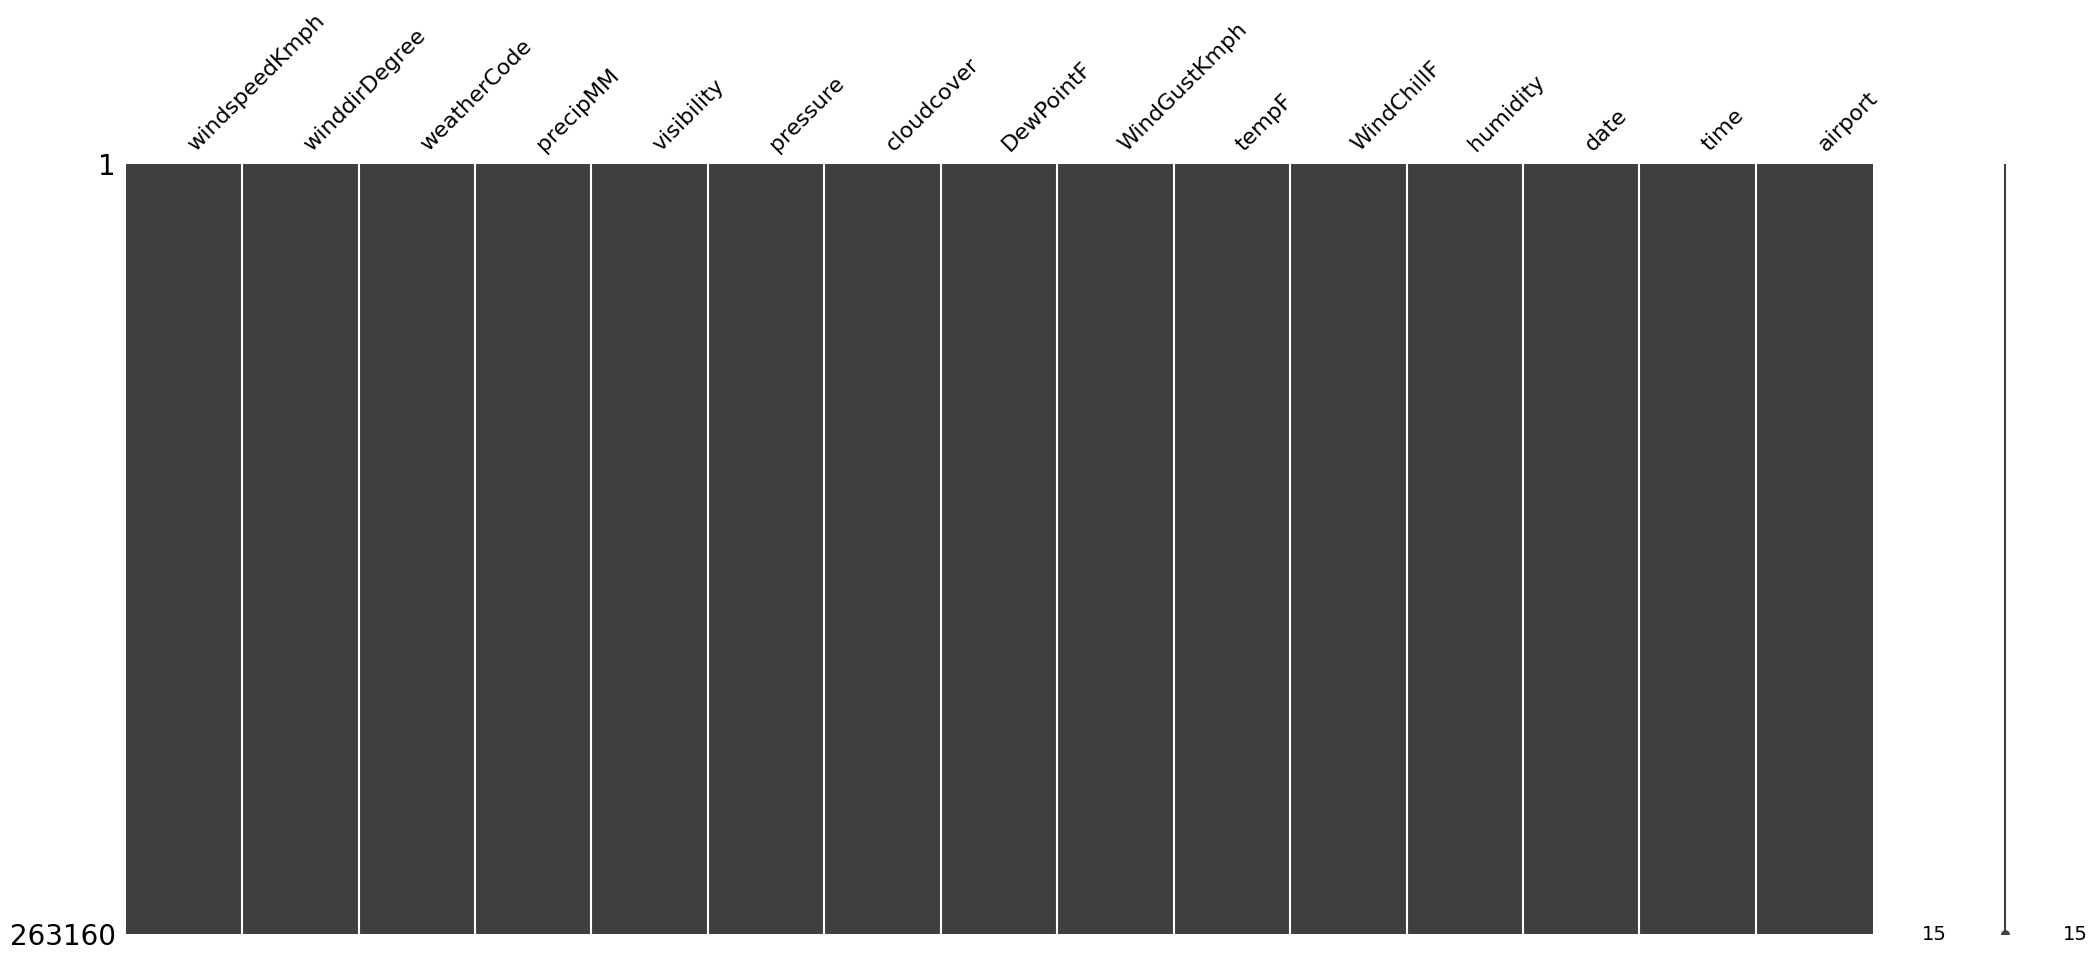

In [6]:
print(msno.matrix(weather_data_df))
print(weather_data_df.isnull().sum())

In [7]:
print(weather_data_df.columns)

Index(['windspeedKmph', 'winddirDegree', 'weatherCode', 'precipMM',
       'visibility', 'pressure', 'cloudcover', 'DewPointF', 'WindGustKmph',
       'tempF', 'WindChillF', 'humidity', 'date', 'time', 'airport'],
      dtype='str')


In [8]:
weather_data_df.tail()

,windspeedKmph,winddirDegree,weatherCode,precipMM,visibility,pressure,cloudcover,DewPointF,WindGustKmph,tempF,WindChillF,humidity,date,time,airport
263155,2,279,116,0.0,10,1019,51,52,5,55,55,92,2017-12-31,1900,SFO
263156,2,255,248,0.0,10,1019,44,53,5,55,55,92,2017-12-31,2000,SFO
263157,1,230,248,0.0,10,1020,38,53,5,55,55,93,2017-12-31,2100,SFO
263158,2,212,248,0.0,10,1020,58,52,4,53,53,95,2017-12-31,2200,SFO
263159,2,194,122,0.0,10,1020,79,51,4,52,52,97,2017-12-31,2300,SFO
